# A plane wave, a cylinder in water, and an interface that shares no node

`Geom/Vibro_ac1.step` holds a 60 mm sphere of water with a 10 x 20 mm cylinder
cut out of it, and the cylinder itself. A plane wave at 60 kHz arrives from
outside, the cylinder scatters it, and the scattered wave has to leave the
model without bouncing off its edge. It is the geometry of the COMSOL
*Acoustic-Structure Interaction* tutorial, and the study here follows it:

| | |
|---|---|
| water | $\rho = 997\ \mathrm{kg/m^3}$, $c = 1500\ \mathrm{m/s}$ |
| frequency | $f = 60\ \mathrm{kHz}$, so $\lambda = 25\ \mathrm{mm}$ |
| incident wave | $p_0 = 1\ \mathrm{Pa}$, direction from $\theta = 4\pi/6$, $\varphi = -\pi/6$ |
| outer boundary | spherical wave radiation at $R = 30\ \mathrm{mm}$ |
| cylinder | **Study 1** sound-hard; **Study 2** aluminium |

Two things make the model awkward for pyCAFE, and both are the subject of the
notebook.

**The mesh.** pyCAFE assembles shells as CQUAD4F quadrilaterals and volumes as
CHEXA8 or CTETRA4, and the conforming coupling needs the shell elements to *be*
faces of the fluid elements. A sphere is not a six-sided solid, so it cannot be
meshed transfinitely into hexahedra; the fluid comes out tetrahedral, and the
faces of a tetrahedron are triangles, which no shell kernel here can use. So
the two domains are meshed **separately** and merged into one file whose
interface shares no node at all, and the coupling is built by the interpolation
method of

> Y. Mi, H. Zheng, *An interpolation method for coupling non-conforming patches
> in isogeometric analysis of vibro-acoustic systems*, Comput. Methods Appl.
> Mech. Engrg. 338 (2018) 264-297.

**The cylinder.** COMSOL solves it as a linear elastic **solid**. pyCAFE has no
3D elastic element -- CHEXA8 and CTETRA4 carry one pressure DOF per node, and
the only structural element is a shell. Study 2 is therefore a 1 mm aluminium
**tube**, not a solid cylinder: the same coupling machinery, a different body.
Section 8 says what that changes and what it does not.

**STEP -> two meshes -> merge -> sound-hard study -> elastic study ->
what the shell changed.**

In [1]:
import os
import sys
import time
import warnings

sys.path.insert(0, os.path.abspath(".."))            # run from examples/

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.tri as mtri
from scipy.spatial import cKDTree

from pycafe.boundary_condition.acoustic_bc import (
    AcousticBC, IncidentPlaneWave, build_radiation_operator,
)
from pycafe.core.model_spec import (
    CadFile, Fluid, ModelSpec, Structure, build_mesh, build_model, preview,
)
from pycafe.create_geom import inspect_cad
from pycafe.solver.solver_helmholtz_1 import solve_helmholtz_frequency_sweep
from pycafe.solver.solver_vibroacoustic import (
    solve_vibroacoustic_frequency_sweep,
)

STEP = "../Geom/Vibro_ac1.step"

# Entity tags, read from inspect_cad below.
SPHERE = [1]                                      # the fluid volume
SPHERE_SKIN = [1, 2, 3, 4, 5, 6, 7, 8]            # its outer surface, in octants
CYLINDER_SIDE = [9, 10, 13, 14, 15, 17, 18, 20]   # the shell

# COMSOL's data, table for table.
WATER = Fluid(997.0, 1500.0, "water")
ALUMINIUM = Structure(t=1.0e-3, E=69e9, nu=0.33, rho_s=2730.0,
                      support="free", name="Aluminum 3003-H18")
F = 60e3
P0 = 1.0
THETA, PHI = 4 * np.pi / 6, -np.pi / 6
DIRECTION = (np.sin(THETA) * np.cos(PHI),
             np.sin(THETA) * np.sin(PHI),
             np.cos(THETA))
R = 0.03

# The unstructured mesher only approaches the size it is given on a curved
# boundary, so the density is asked high and the validator reports what was
# actually obtained.
PER_WAVELENGTH = 16

plt.rcParams["figure.dpi"] = 110

## 1. What is in the STEP file

A CAD file carries no roles, so the first move is always the same: list what is
inside it and read the tags off the table.

In [2]:
entities = inspect_cad(STEP, units="mm")

sphere, cylinder = entities[3][0], entities[3][1]
print()
print(f"sphere volume   {sphere.size:.4e} m3   "
      f"(a full sphere of the same bbox would be "
      f"{np.pi / 6 * (sphere.bbox_max - sphere.bbox_min).prod():.4e})")
print(f"cylinder volume {cylinder.size:.4e} m3")
print()
print("The difference is exactly the cylinder: the sphere is drawn with the")
print("cylinder already cut out of it, so the two solids touch on a common")
print("surface -- the wet side of the shell.")
print()
print("Units: the largest number in the file is 60. 'auto' would read that as")
print("metres (it only switches to millimetres above 100), so the unit is")
print("stated explicitly: units='mm' -> a 60 mm sphere around a 10 x 20 mm")
print("cylinder.")

../Geom/Vibro_ac1.step  (scaled by 0.001 to metres)
  dim 3  tag    1   volume 1.115e-04   bbox 0.060 x 0.060 x 0.085   centre (-0.000, -0.000, 0.000)
  dim 3  tag    2   volume 1.571e-06   bbox 0.010 x 0.010 x 0.020   centre (0.000, -0.000, 0.000)
  dim 2  tag    1   area   1.414e-03   bbox 0.045 x 0.045 x 0.042   centre (0.015, 0.015, 0.015)
  dim 2  tag    5   area   1.414e-03   bbox 0.045 x 0.045 x 0.042   centre (-0.015, 0.015, 0.015)
  dim 2  tag    3   area   1.414e-03   bbox 0.045 x 0.045 x 0.042   centre (0.015, -0.015, 0.015)
  dim 2  tag    7   area   1.414e-03   bbox 0.045 x 0.045 x 0.042   centre (-0.015, -0.015, 0.015)
  dim 2  tag    8   area   1.414e-03   bbox 0.045 x 0.045 x 0.042   centre (-0.015, -0.015, -0.015)
  dim 2  tag    4   area   1.414e-03   bbox 0.045 x 0.045 x 0.042   centre (0.015, -0.015, -0.015)
  dim 2  tag    6   area   1.414e-03   bbox 0.045 x 0.045 x 0.042   centre (-0.015, 0.015, -0.015)
  dim 2  tag    2   area   1.414e-03   bbox 0.045 x 0.045 x 0

## 2. Why one mesh cannot serve both domains

Meshed in a single pass, this geometry gives what the validator says below.
`_try_structured` looks for six-sided volumes with four-sided faces — the shape
a transfinite hexahedral mesh needs — and a sphere has eight faces, so the
volume falls back to tetrahedra. With `recombine=True` on top of that, Gmsh
puts quadrilaterals on the surfaces and fills the gap with **pyramids**, which
pyCAFE has no kernel for: the fluid would be assembled with holes in it.

In [3]:
single_pass = ModelSpec(
    geometry=CadFile(STEP, units="mm", recombine=True,
                     fluid=SPHERE, structure=CYLINDER_SIDE,
                     boundaries={"radiation": SPHERE_SKIN}),
    fluid=WATER, structure=ALUMINIUM,
    f_max=20e3, work_dir=".", output_path="scatter_single.msh",
)

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    try:
        build_mesh(single_pass)
    except RuntimeError as exc:
        print(exc)

the mesh does not satisfy the pyCAFE contract:
scatter_single.msh  (vibroacoustic analysis)
--------------------------------------------
  1002 nodes, 513 x Quadrilateral 4, 3129 x Tetrahedron 4, 477 x Pyramid 5
  roles: fluid = 'fluid', structure = 'plate'
  ERROR: only 3.2 elements per wavelength at 20000 Hz: below the practical minimum of 6, the result is dispersion, not physics.
  · fluid element size: 2.2 / 11.4 / 23.1 mm (min / mean / max)
  · good to ~1% up to 4991 Hz (13 elements per wavelength at c0 = 1500 m/s)
  · at 20000 Hz: 3.2 elements per wavelength, dispersion error ~15.58%
  · selectable boundaries: radiation, rigid_walls
  => NOT usable


## 3. Two meshes, one file

`independent_structure=True` runs two meshing passes on the same CAD file:

1. the **fluid** alone, unstructured, tetrahedral (`recombine=False`, so no
   pyramids are created);
2. the **shell** alone, recombined into quadrilaterals and transfinite where
   the patch has four sides.

The two are then merged by `pycafe.create_geom.merge.merge_meshes`, which
renumbers the second set of nodes so that **nothing is shared**. That is not an
accident to be repaired later: the two surfaces are the same surface described
twice, and the coupling is what reconciles them.

The cylinder *solid* is dropped before either pass: pyCAFE models it by its
surface, so meshing its interior would only add nodes that belong to no
equation. Its surfaces stay — one of them is the wet side of the shell.

The mesh size still comes from `f_max`, here 60 kHz in water.

**The geometry is drawn before anything is assembled** — `preview` meshes,
validates and plots, and nothing else.

In [4]:
spec = ModelSpec(
    geometry=CadFile(
        STEP, units="mm", recombine=False,
        fluid=SPHERE,
        structure=CYLINDER_SIDE,
        boundaries={"radiation": SPHERE_SKIN},
        independent_structure=True,      # two passes, merged
        structure_element_size=1.5e-3,   # the shell can be finer than the water
    ),
    fluid=WATER,
    structure=ALUMINIUM,
    f_max=F,
    elements_per_wavelength=PER_WAVELENGTH,
    work_dir=".", output_path="scatter_coupled.msh",
)
print(spec.describe())

ModelSpec
  geometry     CadFile(path=PosixPath('../Geom/Vibro_ac1.step'), fluid=[1], structure=[9, 10, 13, 14, 15, 17, 18, 20], clamp='auto', boundaries={'radiation': [1, 2, 3, 4, 5, 6, 7, 8]}, walls='rigid_walls', units='mm', dim=3, recombine=False, independent_structure=True, structure_element_size=0.0015)
  fluid        water: rho0 = 997.0 kg/m3, c0 = 1500.0 m/s
  structure    Aluminum 3003-H18: t = 1.00 mm, E = 69 GPa, nu = 0.33, rho = 2730.0 kg/m3, free
  f_max        60000.0 Hz (lambda = 25 mm)
  mesh size    1.6 mm (16 elements per wavelength)
  mesh file    scatter_coupled.msh
  bending      lambda_b = 13 mm at f_max  (shorter than the acoustic one: check the panel mesh)


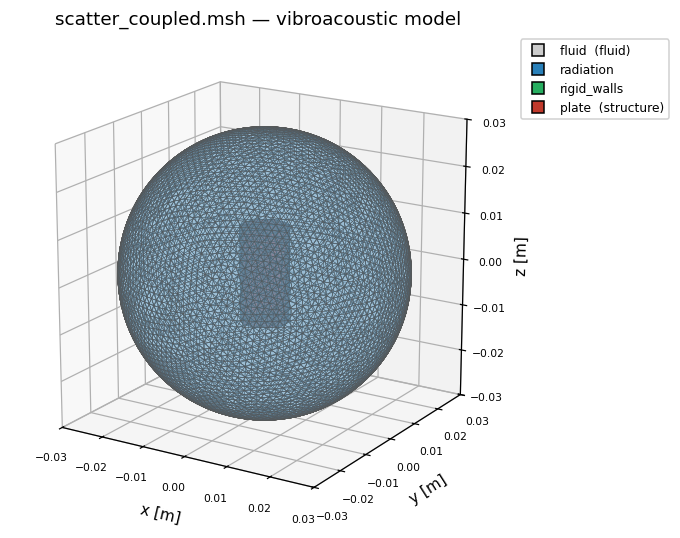

scatter_coupled.msh  (vibroacoustic analysis)
---------------------------------------------
  27506 nodes, 12806 x Triangle 3, 735 x Quadrilateral 4, 147015 x Tetrahedron 4
  roles: fluid = 'fluid', structure = 'plate'
  · fluid element size: 1.1 / 2.2 / 3.1 mm (min / mean / max)
  · good to ~1% up to 37699 Hz (13 elements per wavelength at c0 = 1500 m/s)
  · at 60000 Hz: 8.2 elements per wavelength, dispersion error ~2.46%
  · selectable boundaries: radiation, rigid_walls
  => usable


In [5]:
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    mesh_path, mesh_report = preview(spec, elev=18, azim=-58, figsize=(11, 5))

The two warnings about the interface are the point of this notebook, not a
problem to fix: the mesh is *usable*, and says how the coupling will be built.

## 4. The wave, and the boundary that lets it through

Two conditions have to hold on the outer sphere at once: the scattered wave
must leave, and the incident wave must come in. `add_spherical_radiation`
carries both.

On a spherical boundary the first-order radiation condition is

$$\frac{\partial p}{\partial n} + \left(jk + \frac{1}{r}\right) p = 0,$$

and the plane-wave (anechoic) condition of the other notebooks is its
$r \to \infty$ limit. Here $kR = 7.5$, so the difference is not dramatic —
but it is free, and the boundary is a sphere by construction.

The incident field is declared as part of the same condition, exactly as
COMSOL makes *Incident Pressure Field* a subfeature of *Spherical Wave
Radiation*. Writing the total field as $p = p_i + p_s$ and asking only the
scattered part to leave gives

$$\frac{\partial p}{\partial n} + \left(jk + \frac1r\right) p
  = \frac{\partial p_i}{\partial n} + \left(jk + \frac1r\right) p_i,$$

whose right-hand side is a load vector. The solution is then the **total**
field, and the scattered field is what is left after subtracting $p_i$.

In [6]:
omega = 2 * np.pi * F
k = omega / WATER.c0

wave = IncidentPlaneWave(p0=P0, direction=DIRECTION)
bc = AcousticBC().add_spherical_radiation("radiation", incident=wave)

print(f"lambda = {WATER.c0 / F * 1e3:.1f} mm over a {2 * R * 1e3:.0f} mm "
      f"domain -> {2 * R / (WATER.c0 / F):.1f} wavelengths across")
print(f"k = {k:.1f} rad/m,  kR = {k * R:.2f}")
print(f"incident direction (k1, k2, k3) = "
      f"({DIRECTION[0]:.4f}, {DIRECTION[1]:.4f}, {DIRECTION[2]:.4f})")

lambda = 25.0 mm over a 60 mm domain -> 2.4 wavelengths across
k = 251.3 rad/m,  kR = 7.54
incident direction (k1, k2, k3) = (0.7500, -0.4330, -0.5000)


## 5. Study 1 — the sound-hard cylinder

COMSOL runs this one by switching Solid Mechanics off, which leaves the
cylinder surface as a wall the sound cannot enter. In pyCAFE a wall is the
natural condition: mesh the water alone, name no structure, and the surface of
the hole is rigid because nothing says otherwise.

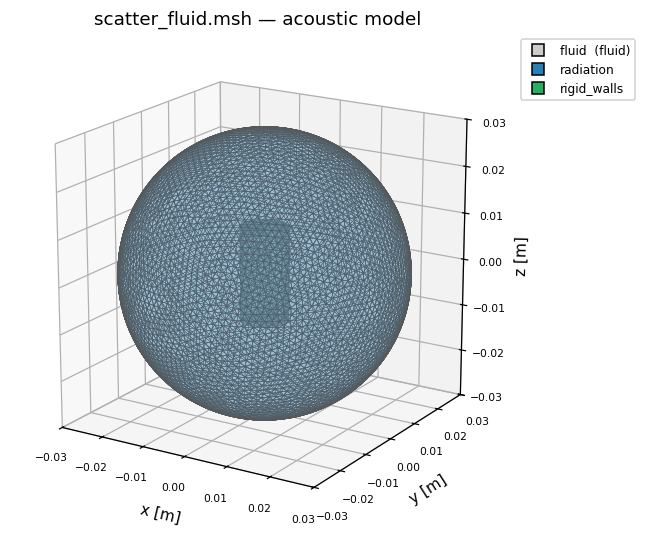

Acoustic domain from physical group 'fluid': CTETRA4


In [7]:
hard_spec = ModelSpec(
    geometry=CadFile(STEP, units="mm", recombine=False, fluid=SPHERE,
                     boundaries={"radiation": SPHERE_SKIN}),
    fluid=WATER, f_max=F, elements_per_wavelength=PER_WAVELENGTH,
    work_dir=".", output_path="scatter_fluid.msh",
)

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    hard = build_model(hard_spec, bc=bc, show=True,
                       plot_kwargs=dict(elev=18, azim=-58, figsize=(11, 5)))

In [8]:
t0 = time.time()
P = solve_helmholtz_frequency_sweep(
    hard["system"]["K_red"], hard["system"]["M_red"], hard["system"]["C_red"],
    np.array([F]),
    hard["system"]["pressure_nodes_red"], hard["system"]["pressure_values"],
    nodes=hard["nodes"], idx_free=hard["system"]["idx_free"], rho=WATER.rho0,
    impedance_operator=hard["system"]["C_red_op"],
    radiation_operator=hard["system"]["radiation_red_op"],
)

p_hard = np.zeros(hard["nodes"].shape[0], dtype=complex)
p_hard[hard["system"]["idx_free"]] = P[:, 0]
p_inc = hard["system"]["radiation_op"].incident_field(hard["nodes"], omega)
p_scat_hard = p_hard - p_inc

print(f"solved in {time.time() - t0:.1f} s on "
      f"{hard['nodes'].shape[0]} nodes")
print(f"|p| total     max {np.abs(p_hard).max():.3f} Pa")
print(f"|p| scattered max {np.abs(p_scat_hard).max():.3f} Pa   "
      f"(the incident wave is 1 Pa everywhere)")

solved in 6.2 s on 26723 nodes
|p| total     max 1.798 Pa
|p| scattered max 0.935 Pa   (the incident wave is 1 Pa everywhere)


The field is cut on the plane $y = 0$, which contains neither the cylinder axis
alone nor the incident direction alone, but is the plane COMSOL plots. The
incident wave is a set of parallel stripes; the total field is what the
cylinder makes of them; the difference between the two is the scattered wave,
which is what actually has to leave through the boundary.

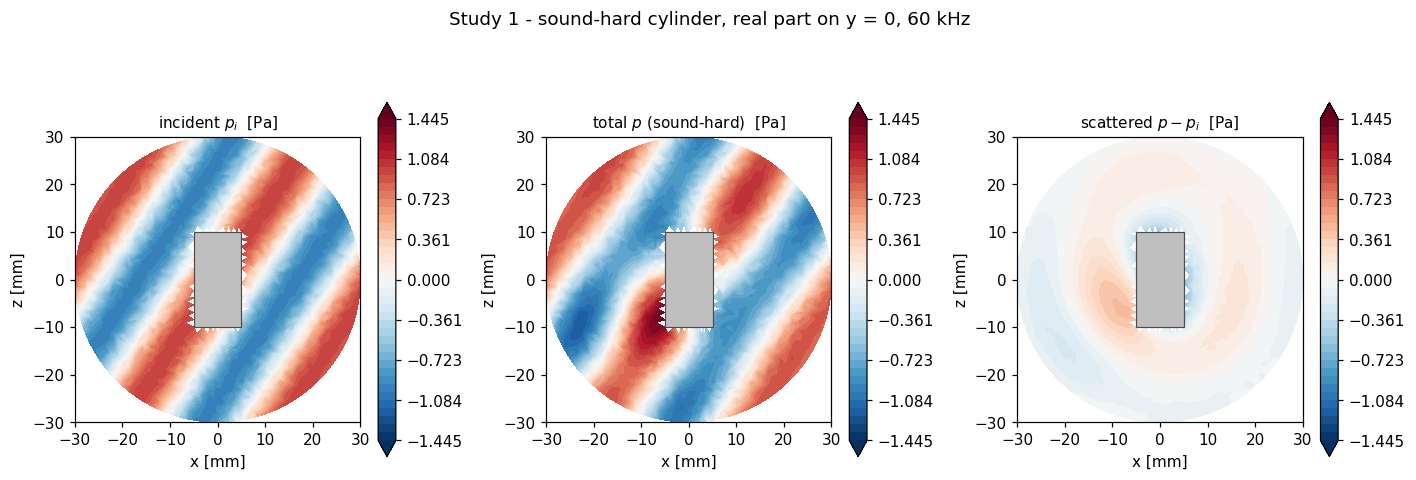

In [9]:
def slice_plot(ax, nodes, field, title, half_width=1.2e-3, cmap="RdBu_r",
               levels=41, symmetric=True, vmax=None):
    """Nodal field on the y = 0 plane, drawn as a triangulation of (x, z)."""
    band = np.abs(nodes[:, 1]) < half_width
    x, z = nodes[band, 0] * 1e3, nodes[band, 2] * 1e3
    values = field[band]
    tri = mtri.Triangulation(x, z)
    # Drop the triangles that bridge the hole left by the cylinder.
    centres = np.column_stack([x[tri.triangles].mean(axis=1),
                               z[tri.triangles].mean(axis=1)])
    inside = (np.abs(centres[:, 0]) < 5.6) & (np.abs(centres[:, 1]) < 10.6)
    tri.set_mask(inside)
    limit = vmax if vmax is not None else np.abs(values).max()
    bounds = np.linspace(-limit, limit, levels) if symmetric else \
        np.linspace(0.0, limit, levels)
    art = ax.tricontourf(tri, values, levels=bounds, cmap=cmap, extend="both")
    ax.add_patch(plt.Rectangle((-5, -10), 10, 20, fc="0.75", ec="0.3", lw=0.8))
    ax.set_aspect("equal")
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("x [mm]")
    ax.set_ylabel("z [mm]")
    return art


fig, axes = plt.subplots(1, 3, figsize=(13, 4.4))
limit = np.abs(p_hard.real).max()
for ax, field, title in zip(
    axes,
    (p_inc, p_hard, p_scat_hard),
    ("incident $p_i$", "total $p$ (sound-hard)", "scattered $p - p_i$"),
):
    art = slice_plot(ax, hard["nodes"], field.real, title + "  [Pa]",
                     vmax=limit)
    fig.colorbar(art, ax=ax, shrink=0.85)
fig.suptitle("Study 1 - sound-hard cylinder, real part on y = 0, 60 kHz",
             y=1.02)
fig.tight_layout()
plt.show()

## 6. Study 2 — the cylinder as an aluminium shell

Now the cylinder is allowed to move. The coupled system is the one the mesh
already describes: water tetrahedra, shell quadrilaterals, and an interface
whose two sides share no node, so `Kc` is built by interpolation. The same
radiation operator carries the incident wave; it is passed to the coupled
sweep, which adds its matrix to the acoustic block and its load to the
right-hand side.

The shell is **free** — nothing holds a cylinder floating in water — which is
legitimate here because at 60 kHz the inertia term $-\omega^2 M_s$ keeps the
structural block invertible without any constraint.

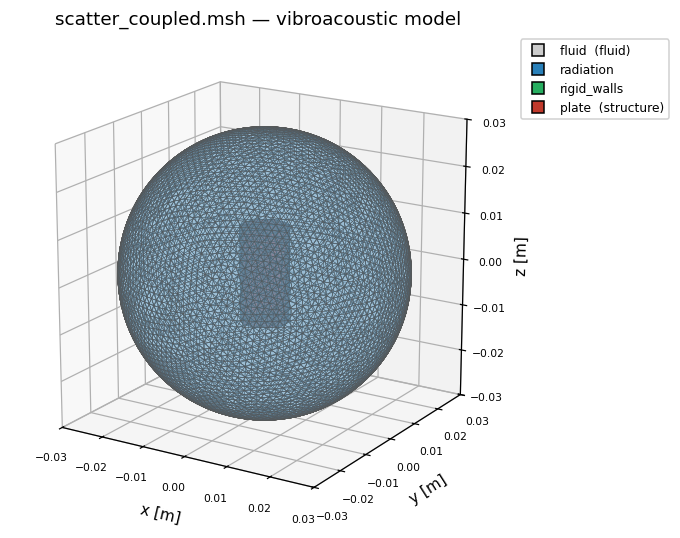

radiation boundary: 113.0 cm2, radius 30.00 mm, off-sphere by 0.00%


In [10]:
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    coupled = build_model(spec, show=True,
                          plot_kwargs=dict(elev=18, azim=-58, figsize=(11, 5)))

radiation = build_radiation_operator(
    bc, nodes=coupled["nodes"], c0=WATER.c0,
    boundaries=coupled["boundaries"], groups=coupled["groups"],
    elements=coupled["elements"],
)
print(f"radiation boundary: {radiation.terms[0].area * 1e4:.1f} cm2, "
      f"radius {radiation.terms[0].radius * 1e3:.2f} mm, "
      f"off-sphere by {radiation.terms[0].spread:.2%}")

In [11]:
t0 = time.time()
elastic = solve_vibroacoustic_frequency_sweep(
    coupled["system"], [F], radiation_operator=radiation, verbose=False,
)
print(f"coupled solve in {time.time() - t0:.1f} s on "
      f"{elastic['w'].shape[0]} structural + {elastic['p'].shape[0]} "
      f"acoustic unknowns")

w = elastic["w"][:, 0]
dofs = coupled["system"]["domains"]["structure"]["spec"].dofs_per_node
u = np.abs(w.reshape(-1, dofs)[:, :3]).max(axis=1)
print(f"|u| max on the shell: {u.max() * 1e12:.2f} pm under a 1 Pa wave")
print(f"    surface velocity  {u.max() * omega * 1e6:.3f} um/s")
print(f"    which radiates    {WATER.Z0 * u.max() * omega:.3f} Pa "
      f"into the water")

coupled solve in 9.7 s on 4698 structural + 26723 acoustic unknowns
|u| max on the shell: 3.58 pm under a 1 Pa wave
    surface velocity  1.349 um/s
    which radiates    2.018 Pa into the water


A few picometres. It looks like nothing, and it is not: the characteristic
impedance of water is 1.5 MPa s/m, so a surface creeping along at a micrometre
per second already speaks at the level of the pascal that arrived. That is the
whole reason a stiff metal tube is not the same scatterer as a wall.

## 7. What the shell changed

The two studies live on different meshes — the sound-hard one has no shell in
it — but the water is meshed from the same CAD with the same size, so the two
sets of fluid nodes are the same points in a different order. Matching them by
coordinate makes the comparison exact rather than interpolated.

In [12]:
fluid_nodes0 = np.asarray(
    coupled["system"]["domains"]["fluid"]["nodes"], dtype=int) - 1
tree = cKDTree(hard["nodes"])
distance, mapping = tree.query(coupled["nodes"][fluid_nodes0], k=1)
matched = distance < 1e-12
print(f"{matched.sum()} of {fluid_nodes0.size} water nodes matched exactly")

p_elastic = np.zeros(coupled["nodes"].shape[0], dtype=complex)
p_elastic[elastic["idx_a"]] = elastic["p"][:, 0]

here = fluid_nodes0[matched]
there = mapping[matched]
change = (np.linalg.norm(p_elastic[here] - p_hard[there])
          / np.linalg.norm(p_hard[there]))
print(f"|p| max, sound-hard : {np.abs(p_hard[there]).max():.3f} Pa")
print(f"|p| max, aluminium  : {np.abs(p_elastic[here]).max():.3f} Pa")
print(f"the shell changes the field by {change:.1%} in norm")

26723 of 26723 water nodes matched exactly
|p| max, sound-hard : 1.798 Pa
|p| max, aluminium  : 2.311 Pa
the shell changes the field by 20.9% in norm


Before reading anything into that number, one control. Make the same shell
stiff and heavy enough to be a wall, and the coupled model has to fall back
onto the sound-hard answer — which is a check of the interpolated interface as
much as of the radiation condition, since the two paths share nothing but the
geometry.

In [13]:
WALL = Structure(t=1.0e-3, E=69e15, nu=0.33, rho_s=2.73e6,
                 support="free", name="a shell pretending to be a wall")
wall_spec = ModelSpec(geometry=spec.geometry, fluid=WATER, structure=WALL,
                      f_max=F, elements_per_wavelength=PER_WAVELENGTH,
                      work_dir=".", output_path="scatter_coupled.msh")

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    wall = build_model(wall_spec, show=False)
rigid = solve_vibroacoustic_frequency_sweep(
    wall["system"], [F], radiation_operator=radiation, verbose=False,
)

p_rigid = np.zeros(coupled["nodes"].shape[0], dtype=complex)
p_rigid[rigid["idx_a"]] = rigid["p"][:, 0]
residual = (np.linalg.norm(p_rigid[here] - p_hard[there])
            / np.linalg.norm(p_hard[there]))
print(f"|p| max, stiff shell : {np.abs(p_rigid[here]).max():.4f} Pa")
print(f"|p| max, sound-hard  : {np.abs(p_hard[there]).max():.4f} Pa")
print(f"difference           : {residual:.3%}")
print()
print(f"The interpolated interface and the rigid wall agree to {residual:.3%}, "
      f"the error\nfloor of this model. The aluminium shell moves the field "
      f"{change:.1%}, some\n{change / residual:.0f} times further, so Study 2 "
      f"shows the tube and not the interface.")

|p| max, stiff shell : 1.7970 Pa
|p| max, sound-hard  : 1.7982 Pa
difference           : 0.034%

The interpolated interface and the rigid wall agree to 0.034%, the error
floor of this model. The aluminium shell moves the field 20.9%, some
622 times further, so Study 2 shows the tube and not the interface.


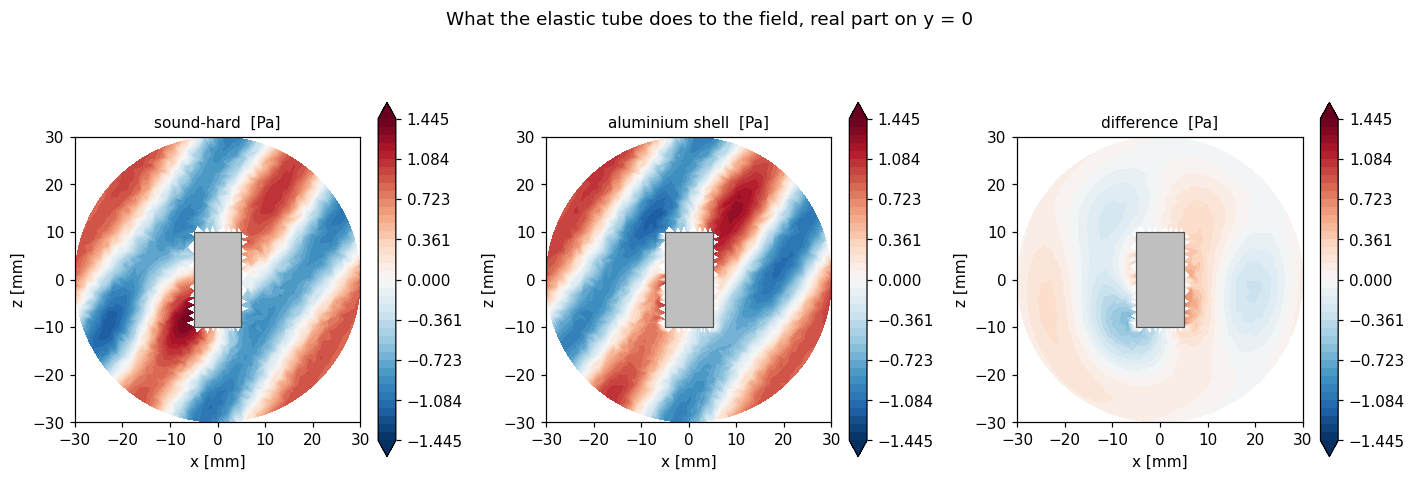

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4.4))
limit = np.abs(p_hard.real).max()
slice_plot(axes[0], hard["nodes"], p_hard.real,
           "sound-hard  [Pa]", vmax=limit)
slice_plot(axes[1], coupled["nodes"], p_elastic.real,
           "aluminium shell  [Pa]", vmax=limit)
difference = np.zeros(coupled["nodes"].shape[0])
difference[here] = (p_elastic[here] - p_hard[there]).real
art = slice_plot(axes[2], coupled["nodes"], difference,
                 "difference  [Pa]", vmax=limit)
for ax in axes:
    fig.colorbar(art, ax=ax, shrink=0.85)
fig.suptitle("What the elastic tube does to the field, real part on y = 0",
             y=1.02)
fig.tight_layout()
plt.show()

## 8. What this case is, and what it is not

**It is** the COMSOL geometry, the COMSOL data and the COMSOL boundary
conditions: water at 997 kg/m³ and 1500 m/s, a 1 Pa plane wave at 60 kHz
arriving from $(\theta, \varphi) = (4\pi/6, -\pi/6)$, spherical wave radiation
on a 30 mm sphere, and the two studies COMSOL runs one after the other.

**It is not** the same solid. COMSOL meshes the cylinder as a linear elastic
volume; pyCAFE has no 3D elastic element, so Study 2 is a 1 mm aluminium
**tube** with rigid end caps — a hollow body of about a fifth of the mass and a
quite different set of resonances. The scattered field will not match COMSOL's
number for number, and it is not meant to.

**The interface costs something.** The stiff-shell control above says how much
on this mesh: that is the error floor of the interpolated coupling here, and
the aluminium result is only worth reading because it moves the field several
times further than that floor.

**The mesh is the binding constraint.** The validator reports the elements per
wavelength actually obtained, not the ones requested: on an unstructured
tetrahedral mesh of a curved body Gmsh treats the size as an upper bound it
only approaches, and the largest elements come out about twice the target.
Asking for 16 per wavelength is how one gets 7 or 8.

What to change to go further: a 3D elastic element (CHEXA8 or CTETRA4 with
three displacement DOFs per node) and its coupling matrix would make this the
COMSOL model rather than a relative of it. Everything else — the geometry, the
radiation condition, the incident field, the non-conforming interface — is
already here.